<a href="https://colab.research.google.com/github/nshub18/Solving-the-Lid-Driven-Cavity-Problem-Using-PINNs/blob/main/Solving%20the%20Lid-Driven%20Cavity%20Problem%20Using%20PINNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting training script...


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['pinn_2/dense_32/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 0, Loss: 0.56966
Epoch 100, Loss: 0.09866
Epoch 200, Loss: 0.09339
Epoch 300, Loss: 0.08068
Epoch 400, Loss: 0.02679
Epoch 500, Loss: 0.02394
Epoch 600, Loss: 0.02193
Epoch 700, Loss: 0.02167
Epoch 800, Loss: 0.02036
Epoch 900, Loss: 0.01949
Epoch 1000, Loss: 0.01905
Epoch 1100, Loss: 0.01862
Epoch 1200, Loss: 0.01879
Epoch 1300, Loss: 0.01786
Epoch 1400, Loss: 0.01765
Epoch 1500, Loss: 0.01746
Epoch 1600, Loss: 0.01704
Epoch 1700, Loss: 0.01685
Epoch 1800, Loss: 0.01672
Epoch 1900, Loss: 0.01632
Epoch 2000, Loss: 0.01669
Epoch 2100, Loss: 0.01616
Epoch 2200, Loss: 0.01621
Epoch 2300, Loss: 0.01582
Epoch 2400, Loss: 0.01604
Epoch 2500, Loss: 0.01556
Epoch 2600, Loss: 0.01540
Epoch 2700, Loss: 0.01523
Epoch 2800, Loss: 0.01494
Epoch 2900, Loss: 0.01512
Epoch 3000, Loss: 0.01505
Epoch 3100, Loss: 0.01445
Epoch 3200, Loss: 0.01419
Epoch 3300, Loss: 0.01453
Epoch 3400, Loss: 0.01382
Epoch 3500, Loss: 0.01370
Epoch 3600, Loss: 0.01355
Epoch 3700, Loss: 0.01340
Epoch 3800, Loss: 0.0135

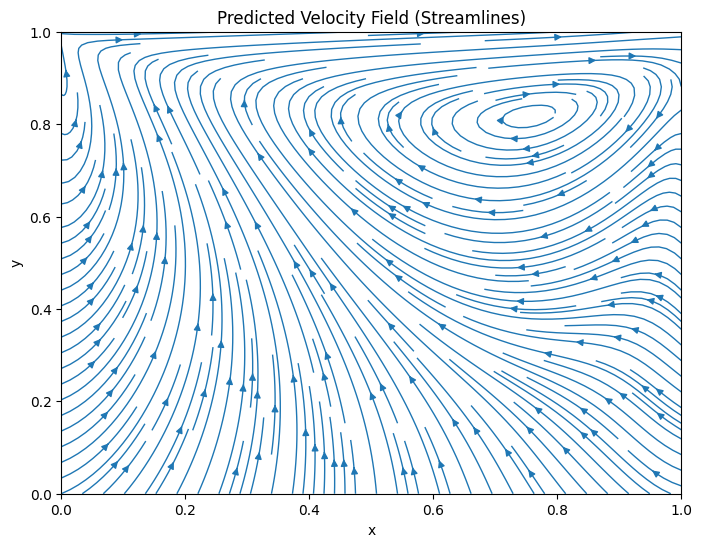

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Problem Configuration & Hyperparameters
# ==========================================
x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0
U_lid = 1.0
nu = 0.01  # Kinematic viscosity (Reynolds number Re = 100)

# ==========================================
# 2. Neural Network Architecture
# ==========================================
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.hidden_layers = []
        num_hidden_layers = 8
        num_neurons_per_layer = 20

        for _ in range(num_hidden_layers):
            layer = tf.keras.layers.Dense(
                num_neurons_per_layer,
                activation='tanh',
                kernel_initializer='glorot_normal'
            )
            self.hidden_layers.append(layer)

        self.u_output = tf.keras.layers.Dense(1, activation=None)
        self.v_output = tf.keras.layers.Dense(1, activation=None)
        self.p_output = tf.keras.layers.Dense(1, activation=None)

    def call(self, inputs):
        x, y = inputs[:, 0:1], inputs[:, 1:2]
        X = tf.concat([x, y], axis=1)
        for layer in self.hidden_layers:
            X = layer(X)
        u = self.u_output(X)
        v = self.v_output(X)
        p = self.p_output(X)
        return u, v, p

# ==========================================
# 3. Data Generation (Collocation & Boundary)
# ==========================================
# Interior Collocation Points
N_f = 10_000
x_f = tf.random.uniform((N_f, 1), x_min, x_max, dtype=tf.float32)
y_f = tf.random.uniform((N_f, 1), y_min, y_max, dtype=tf.float32)
X_f_tensor = tf.concat([x_f, y_f], axis=1)

# Boundary Points
N_b = 2_000
# Left Wall (x = 0)
x_left = x_min * tf.ones((N_b // 4, 1), dtype=tf.float32)
y_left = tf.random.uniform((N_b // 4, 1), y_min, y_max, dtype=tf.float32)
# Right Wall (x = 1)
x_right = x_max * tf.ones((N_b // 4, 1), dtype=tf.float32)
y_right = tf.random.uniform((N_b // 4, 1), y_min, y_max, dtype=tf.float32)
# Bottom Wall (y = 0)
x_bottom = tf.random.uniform((N_b // 4, 1), x_min, x_max, dtype=tf.float32)
y_bottom = y_min * tf.ones((N_b // 4, 1), dtype=tf.float32)
# Top Lid (y = 1)
x_top = tf.random.uniform((N_b // 4, 1), x_min, x_max, dtype=tf.float32)
y_top = y_max * tf.ones((N_b // 4, 1), dtype=tf.float32)

# Combine boundary coordinates
X_b_tensor = tf.concat([
    tf.concat([x_left, y_left], axis=1),
    tf.concat([x_right, y_right], axis=1),
    tf.concat([x_bottom, y_bottom], axis=1),
    tf.concat([x_top, y_top], axis=1)
], axis=0)

# Set up velocity conditions for the boundaries
u_top = U_lid * tf.ones((N_b // 4, 1), dtype=tf.float32)
v_top = tf.zeros((N_b // 4, 1), dtype=tf.float32)
u_side = tf.zeros((3 * N_b // 4, 1), dtype=tf.float32)
v_side = tf.zeros((3 * N_b // 4, 1), dtype=tf.float32)

u_b_tensor = tf.concat([u_side, u_top], axis=0)
v_b_tensor = tf.concat([v_side, v_top], axis=0)

# ==========================================
# 4. Loss Function Formulation
# ==========================================
def loss_fn(model, X_f, X_b, u_b, v_b):
    # Compute PDE residuals at interior collocation points
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(X_f)

        # Predict u, v, p
        u_raw, v_raw, p_raw = model(X_f)
        u = tf.squeeze(u_raw)
        v = tf.squeeze(v_raw)
        p = tf.squeeze(p_raw)

        # Compute first-order derivatives
        u_x = tape.gradient(u, X_f)[:, 0]
        u_y = tape.gradient(u, X_f)[:, 1]
        v_x = tape.gradient(v, X_f)[:, 0]
        v_y = tape.gradient(v, X_f)[:, 1]
        p_x = tape.gradient(p, X_f)[:, 0]
        p_y = tape.gradient(p, X_f)[:, 1]

        # Compute second-order derivatives from the first-order derivatives
        u_xx = tape.gradient(u_x, X_f)[:, 0]
        u_yy = tape.gradient(u_y, X_f)[:, 1]
        v_xx = tape.gradient(v_x, X_f)[:, 0]
        v_yy = tape.gradient(v_y, X_f)[:, 1]

    # Continuity equation residual
    continuity = u_x + v_y

    # Momentum equations residuals
    momentum_u = u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    momentum_v = u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)

    # Delete the tape explicitly after all required gradients are computed
    del tape

    # Calculate PDE Loss
    f_pde = tf.reduce_mean(tf.square(continuity)) + \
            tf.reduce_mean(tf.square(momentum_u)) + \
            tf.reduce_mean(tf.square(momentum_v))

    # Calculate Boundary Condition Loss
    u_pred_b, v_pred_b, _ = model(X_b)
    bc_loss = tf.reduce_mean(tf.square(u_pred_b - u_b)) + \
              tf.reduce_mean(tf.square(v_pred_b - v_b))

    return f_pde + bc_loss

# ==========================================
# 5. Training Setup
# ==========================================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model = PINN()

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        loss_value = loss_fn(model, X_f_tensor, X_b_tensor, u_b_tensor, v_b_tensor)
    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_value

# Execution Loop
epochs = 30000
print("Starting training script...")
for epoch in range(epochs):
    loss_value = train_step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss_value.numpy():.5f}")

# ==========================================
# 6. Results Evaluation & Visualization
# ==========================================
nx, ny = 50, 50
x_plot = tf.linspace(x_min, x_max, nx)
y_plot = tf.linspace(y_min, y_max, ny)
X_grid, Y_grid = tf.meshgrid(x_plot, y_plot)
X_flat = tf.reshape(X_grid, [-1])
Y_flat = tf.reshape(Y_grid, [-1])
XY = tf.stack([X_flat, Y_flat], axis=1)

# Predict fields
u_pred, v_pred, _ = model(XY)
u_pred = tf.reshape(u_pred, (ny, nx)).numpy()
v_pred = tf.reshape(v_pred, (ny, nx)).numpy()

# Render Flow Field Streamlines
plt.figure(figsize=(8, 6))
plt.streamplot(
    X_grid.numpy(), Y_grid.numpy(), u_pred, v_pred,
    density=2, linewidth=1, arrowsize=1
)
plt.title('Predicted Velocity Field (Streamlines)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()